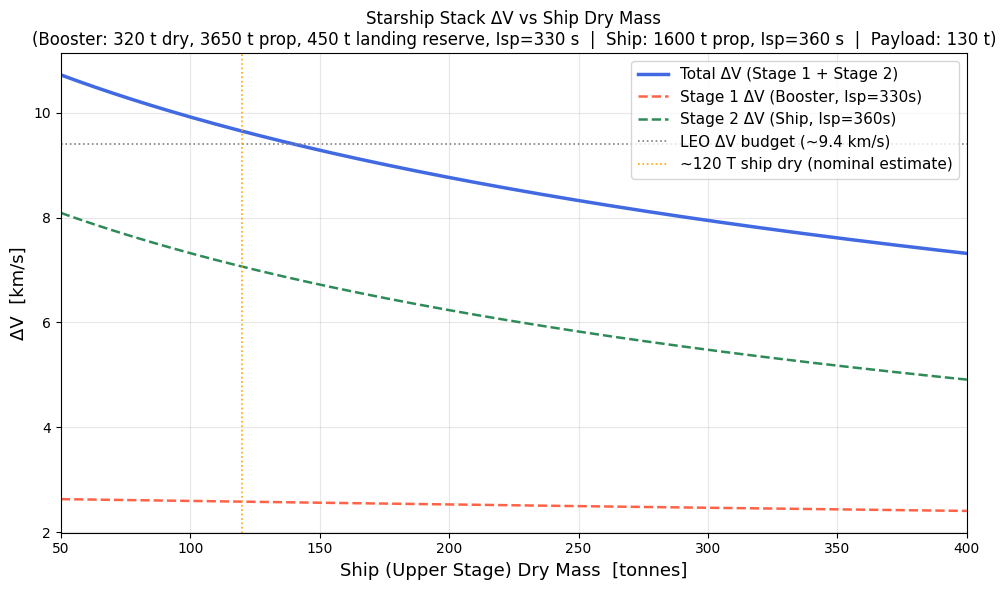

------------------------------------------------------------------------
            50 |             2.631 |             8.090 |           10.721
            75 |             2.614 |             7.687 |           10.301
           100 |             2.597 |             7.325 |            9.921
           124 |             2.580 |             7.013 |            9.593
           150 |             2.563 |             6.727 |            9.290
           175 |             2.546 |             6.469 |            9.015
           199 |             2.530 |             6.241 |            8.771
           225 |             2.514 |             6.026 |            8.540
           250 |             2.498 |             5.828 |            8.326
           274 |             2.482 |             5.651 |            8.133
           300 |             2.467 |             5.481 |            7.948
           325 |             2.451 |             5.323 |            7.774
           349 |             2.436 |   

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g0 = 9.80665  # m/s²

# Fixed parameters
isp1 = 330       # s, booster average ISP
isp2 = 360       # s, ship average ISP
payload = 130e3  # kg
booster_dry =320e3        # kg
booster_prop = 3650e3      # kg
booster_landing_prop = 450e3  # kg, reserved for booster landing burn
ship_prop = 1600e3         # kg

# Sweep ship dry mass
ship_dry_range = np.linspace(50e3, 400e3, 500)  # kg

dv1_list = []
dv2_list = []
dv_total_list = []

for ship_dry in ship_dry_range:
    # Stage 1: full stack at liftoff, booster burns down to landing prop reserve
    m0_s1 = booster_dry + booster_prop + ship_dry + ship_prop + payload
    mf_s1 = booster_dry + booster_landing_prop + ship_dry + ship_prop + payload
    dv1 = isp1 * g0 * np.log(m0_s1 / mf_s1)

    # Stage 2: ship only after staging
    m0_s2 = ship_dry + ship_prop + payload
    mf_s2 = ship_dry + payload
    dv2 = isp2 * g0 * np.log(m0_s2 / mf_s2)

    dv1_list.append(dv1 / 1000)
    dv2_list.append(dv2 / 1000)
    dv_total_list.append((dv1 + dv2) / 1000)

ship_dry_t = ship_dry_range / 1e3  # convert to tonnes for x-axis

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ship_dry_t, dv_total_list, label='Total ΔV (Stage 1 + Stage 2)', color='royalblue', linewidth=2.5)
ax.plot(ship_dry_t, dv1_list,     label=f'Stage 1 ΔV (Booster, Isp={isp1}s)', color='tomato', linestyle='--', linewidth=1.8)
ax.plot(ship_dry_t, dv2_list,     label=f'Stage 2 ΔV (Ship, Isp={isp2}s)',    color='seagreen', linestyle='--', linewidth=1.8)

# Reference lines
ax.axhline(9.4, color='gray', linestyle=':', linewidth=1.2, label='LEO ΔV budget (~9.4 km/s)')
ax.axvline(120, color='orange', linestyle=':', linewidth=1.2, label='~120 T ship dry (nominal estimate)')

ax.set_xlabel('Ship (Upper Stage) Dry Mass  [tonnes]', fontsize=13)
ax.set_ylabel('ΔV  [km/s]', fontsize=13)
ax.set_title(
    f'Starship Stack ΔV vs Ship Dry Mass\n'
    f'(Booster: {booster_dry/1e3:.0f} t dry, {booster_prop/1e3:.0f} t prop, {booster_landing_prop/1e3:.0f} t landing reserve, Isp={isp1} s  |  Ship: {ship_prop/1e3:.0f} t prop, Isp={isp2} s  |  Payload: {payload/1e3:.0f} t)',
    fontsize=12
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(ship_dry_t[0], ship_dry_t[-1])
plt.tight_layout()
plt.show()

# Print a sample table
# print(f'{'Ship Dry [t]':>14} | {'Stage1 ΔV [km/s]':>17} | {'Stage2 ΔV [km/s]':>17} | {'Total ΔV [km/s]':>16}')
print('-' * 72)
for idx in np.linspace(0, len(ship_dry_range)-1, 15, dtype=int):
    print(f'{ship_dry_t[idx]:>14.0f} | {dv1_list[idx]:>17.3f} | {dv2_list[idx]:>17.3f} | {dv_total_list[idx]:>16.3f}')


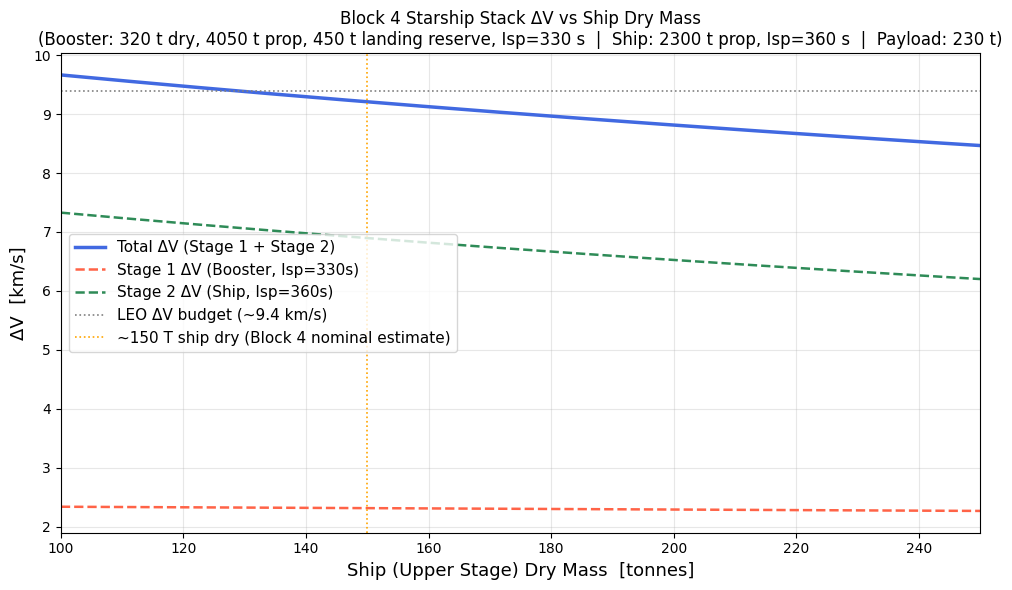

------------------------------------------------------------------------
           100 |             2.337 |             7.328 |            9.665
           111 |             2.332 |             7.231 |            9.563
           121 |             2.327 |             7.135 |            9.462
           132 |             2.321 |             7.045 |            9.366
           143 |             2.316 |             6.955 |            9.272
           154 |             2.311 |             6.868 |            9.180
           164 |             2.306 |             6.787 |            9.093
           175 |             2.301 |             6.705 |            9.006
           186 |             2.296 |             6.626 |            8.922
           196 |             2.291 |             6.552 |            8.842
           207 |             2.286 |             6.477 |            8.763
           218 |             2.281 |             6.405 |            8.685
           228 |             2.276 |   

In [2]:
# Block 4 version of the ΔV vs ship dry mass sweep above
g0 = 9.80665  # m/s²

# Fixed parameters (Block 4)
isp1 = 330       # s, booster average ISP
isp2 = 360       # s, ship average ISP
payload = 230e3  # kg (200t payload + 30t ship landing fuel)
booster_dry = 320e3        # kg
booster_prop = 4050e3      # kg
booster_landing_prop = 450e3  # kg, reserved for booster landing burn
ship_prop = 2300e3         # kg

# Sweep ship dry mass
ship_dry_range = np.linspace(100e3, 250e3, 500)  # kg

dv1_list = []
dv2_list = []
dv_total_list = []

for ship_dry in ship_dry_range:
    # Stage 1: full stack at liftoff, booster burns down to landing prop reserve
    m0_s1 = booster_dry + booster_prop + ship_dry + ship_prop + payload
    mf_s1 = booster_dry + booster_landing_prop + ship_dry + ship_prop + payload
    dv1 = isp1 * g0 * np.log(m0_s1 / mf_s1)

    # Stage 2: ship only after staging
    m0_s2 = ship_dry + ship_prop + payload
    mf_s2 = ship_dry + payload
    dv2 = isp2 * g0 * np.log(m0_s2 / mf_s2)

    dv1_list.append(dv1 / 1000)
    dv2_list.append(dv2 / 1000)
    dv_total_list.append((dv1 + dv2) / 1000)

ship_dry_t = ship_dry_range / 1e3  # convert to tonnes for x-axis

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ship_dry_t, dv_total_list, label='Total ΔV (Stage 1 + Stage 2)', color='royalblue', linewidth=2.5)
ax.plot(ship_dry_t, dv1_list,     label=f'Stage 1 ΔV (Booster, Isp={isp1}s)', color='tomato', linestyle='--', linewidth=1.8)
ax.plot(ship_dry_t, dv2_list,     label=f'Stage 2 ΔV (Ship, Isp={isp2}s)',    color='seagreen', linestyle='--', linewidth=1.8)

# Reference lines
ax.axhline(9.4, color='gray', linestyle=':', linewidth=1.2, label='LEO ΔV budget (~9.4 km/s)')
ax.axvline(150, color='orange', linestyle=':', linewidth=1.2, label='~150 T ship dry (Block 4 nominal estimate)')

ax.set_xlabel('Ship (Upper Stage) Dry Mass  [tonnes]', fontsize=13)
ax.set_ylabel('ΔV  [km/s]', fontsize=13)
ax.set_title(
    f'Block 4 Starship Stack ΔV vs Ship Dry Mass\n'
    f'(Booster: {booster_dry/1e3:.0f} t dry, {booster_prop/1e3:.0f} t prop, {booster_landing_prop/1e3:.0f} t landing reserve, Isp={isp1} s  |  Ship: {ship_prop/1e3:.0f} t prop, Isp={isp2} s  |  Payload: {payload/1e3:.0f} t)',
    fontsize=12
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(ship_dry_t[0], ship_dry_t[-1])
plt.tight_layout()
plt.show()

# Print a sample table
print('-' * 72)
for idx in np.linspace(0, len(ship_dry_range)-1, 15, dtype=int):
    print(f'{ship_dry_t[idx]:>14.0f} | {dv1_list[idx]:>17.3f} | {dv2_list[idx]:>17.3f} | {dv_total_list[idx]:>16.3f}')


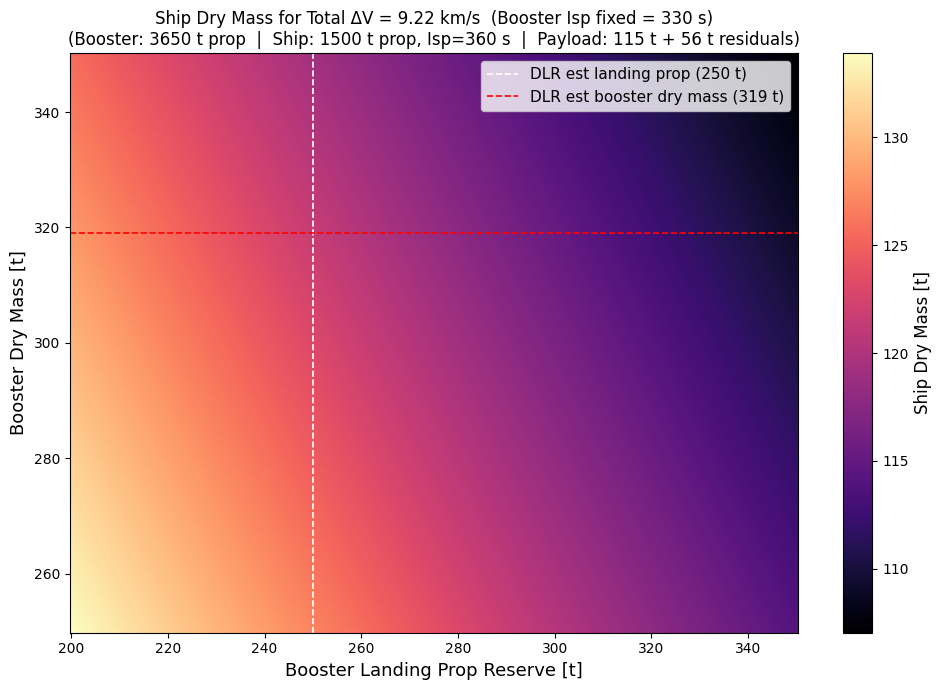

DLR est Starship dry mass: 127.68 t (at booster_landing_prop=250 t, booster_dry=319 t, target ΔV=9.22 km/s)


In [54]:
from scipy.optimize import brentq

blp_range2   = np.linspace(200e3, 350e3, 250)    # booster landing prop [kg]
bdry_range   = np.linspace(250e3, 350e3, 250) # booster dry mass [kg]
target_dv=9.22e3
BLP2, BDRY = np.meshgrid(blp_range2, bdry_range)
ship_dry_solution2 = np.full(BLP2.shape, np.nan)
isp1=330
isp2=360
booster_prop = 3650e3  # kg
ship_prop=1500e3  # kg, fixed ship propellant mass for this analysis
dry_payload=115e3
residuals=56e3
payload=dry_payload + residuals

for i, bdry_val in enumerate(bdry_range):
    for j, blp_val in enumerate(blp_range2):
        def f(ship_dry):
            m0_s1 = bdry_val + booster_prop + ship_dry + ship_prop + dry_payload
            mf_s1 = bdry_val + blp_val      + ship_dry + ship_prop + dry_payload
            dv1 = isp1 * g0 * np.log(m0_s1 / mf_s1)
            m0_s2 = ship_dry + ship_prop + dry_payload
            mf_s2 = ship_dry + dry_payload + residuals
            dv2 = isp2 * g0 * np.log(m0_s2 / mf_s2)
            return dv1 + dv2 - target_dv
        try:
            sol = brentq(f, 1e3, 2000e3)
            ship_dry_solution2[i, j] = sol / 1e3  # tonnes
        except ValueError:
            pass

fig, ax = plt.subplots(figsize=(10, 7))
c = ax.pcolormesh(BLP2 / 1e3, BDRY / 1e3, ship_dry_solution2, cmap='magma', shading='auto')
cbar = fig.colorbar(c, ax=ax)
cbar.set_label('Ship Dry Mass [t]', fontsize=12)
booster_landing_prop = 250e3
booster_dry=319e3

ax.axvline(booster_landing_prop / 1e3, color='white', linestyle='--', linewidth=1.2,
           label=f'DLR est landing prop ({booster_landing_prop/1e3:.0f} t)')
ax.axhline(booster_dry / 1e3, color='red', linestyle='--', linewidth=1.2,
           label=f'DLR est booster dry mass ({booster_dry/1e3:.0f} t)')

ax.set_xlabel('Booster Landing Prop Reserve [t]', fontsize=13)
ax.set_ylabel('Booster Dry Mass [t]', fontsize=13)
ax.set_title(
    f'Ship Dry Mass for Total ΔV = {target_dv/1e3} km/s  (Booster Isp fixed = {isp1} s)\n'
    f'(Booster: {booster_prop/1e3:.0f} t prop  |  Ship: {ship_prop/1e3:.0f} t prop, Isp={isp2} s  |  Payload: {dry_payload/1e3:.0f} t + {residuals/1e3:.0f} t residuals)',
    fontsize=12
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

def _dlr_ship_dry_eq(ship_dry):
    m0_s1 = booster_dry + booster_prop + ship_dry + ship_prop + payload
    mf_s1 = booster_dry + booster_landing_prop + ship_dry + ship_prop + payload
    dv1 = isp1 * g0 * np.log(m0_s1 / mf_s1)
    m0_s2 = ship_dry + ship_prop + payload
    mf_s2 = ship_dry + payload
    dv2 = isp2 * g0 * np.log(m0_s2 / mf_s2)
    return dv1 + dv2 - target_dv

dlr_ship_dry = brentq(_dlr_ship_dry_eq, 1e3, 2000e3)
print(f"DLR est Starship dry mass: {dlr_ship_dry/1e3:.2f} t "
      f"(at booster_landing_prop={booster_landing_prop/1e3:.0f} t, "
      f"booster_dry={booster_dry/1e3:.0f} t, target ΔV={target_dv/1e3:.2f} km/s)")


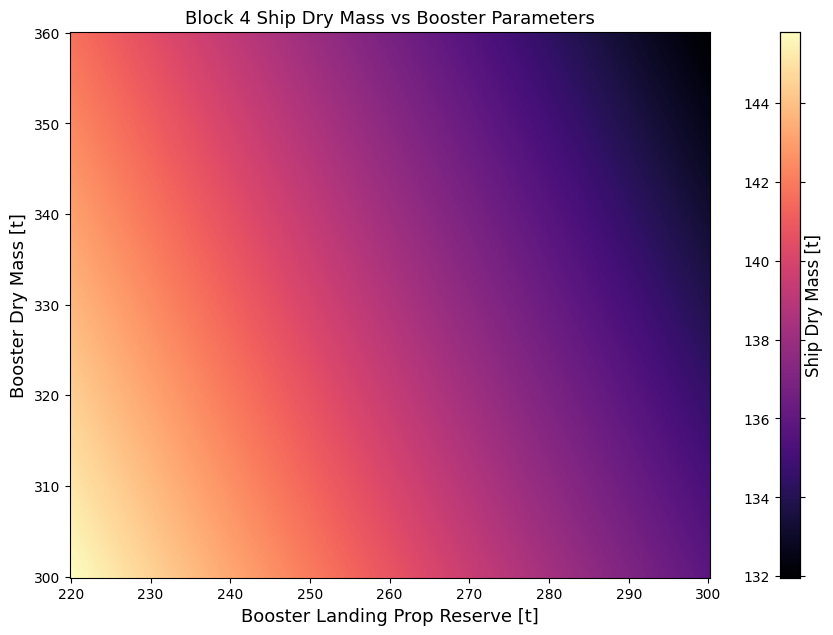

ΔV=9.22 km/s | landing prop=260 t, booster dry=330 t → ship dry=138.7 t


In [ ]:
# Single Block 4 landing prop reserve / booster dry mass colormap for ΔV = 9.2 km/s
g0 = 9.80665  # m/s²

# Fixed parameters (Block 4)
isp1 = 330       # s, booster average ISP
isp2 = 360       # s, ship average ISP
dry_payload = 200e3  # kg
residuals = 56e3     # kg, landing fuel reserved in ship mass budget

payload = dry_payload + residuals
booster_dry = 320e3       # kg
booster_prop = 4050e3     # kg
booster_landing_prop = 300e3  # kg, reserved for booster landing burn
ship_prop = 2300e3        # kg
dry_mass_drop = 0  # ship dry mass reduction if TPS removed

blp_range2 = np.linspace(220e3, 300e3, 250)
bdry_range = np.linspace(300e3, 360e3, 250)
BLP2, BDRY = np.meshgrid(blp_range2, bdry_range)

target_dv = 9.22e3
sol_grid = np.full(BLP2.shape, np.nan)

for i, bdry_val in enumerate(bdry_range):
    for j, blp_val in enumerate(blp_range2):
        def f(ship_dry):
            m0_s1 = bdry_val + booster_prop + ship_dry + ship_prop + dry_payload
            mf_s1 = bdry_val + blp_val      + ship_dry + ship_prop + dry_payload
            dv1 = isp1 * g0 * np.log(m0_s1 / mf_s1)
            m0_s2 = ship_dry + ship_prop + dry_payload
            mf_s2 = ship_dry + dry_payload + residuals
            dv2 = isp2 * g0 * np.log(m0_s2 / mf_s2)
            return dv1 + dv2 - target_dv
        try:
            sol = brentq(f, 1e3, 2000e3)
            sol_grid[i, j] = sol / 1e3
        except ValueError:
            pass

payload_10t = 10e3

fig, ax = plt.subplots(figsize=(10, 7))
fig.subplots_adjust(left=0.10, right=0.74, bottom=0.10, top=0.88)

c = ax.pcolormesh(BLP2 / 1e3, BDRY / 1e3, sol_grid, cmap='magma', shading='auto')
ax.set_xlabel('Booster Landing Prop Reserve [t]', fontsize=13)
ax.set_ylabel('Booster Dry Mass [t]', fontsize=13)
ax.set_title('Block 4 Ship Dry Mass vs Booster Unknowns', fontsize=13)

cax = fig.add_axes([0.81, 0.10, 0.02, 0.78])
cbar = fig.colorbar(c, cax=cax)
cbar.set_label('Ship Dry Mass [t]', fontsize=12)

# Mass ratio ticks for 10t payload on right side of colorbar
cbar_ax2 = cbar.ax.twinx()
cbar_ax2.set_ylim(cbar.ax.get_ylim())
cbar_ticks = cbar.get_ticks()
clim = cbar.ax.get_ylim()
cbar_ticks_filtered = [t for t in cbar_ticks if clim[0] <= t <= clim[1]]
mass_ratio_labels = []
# for t in cbar_ticks_filtered:
#     sd_kg = t * 1e3
#     mr = (sd_kg + ship_prop + payload_10t - dry_mass_drop) / (sd_kg + payload_10t - dry_mass_drop)
#     mass_ratio_labels.append(f'{mr:.2f}')
cbar_ax2.set_yticks(cbar_ticks_filtered)
cbar_ax2.set_yticklabels(mass_ratio_labels)
# cbar_ax2.set_ylabel('Ship Mass Ratio (10 t payload)', fontsize=12)

plt.show()

# Print ship dry mass at midpoint of sweep ranges
mid_i = len(bdry_range) // 2
mid_j = len(blp_range2) // 2
mid_blp = (blp_range2[0] + blp_range2[-1]) / 2
mid_bdry = (bdry_range[0] + bdry_range[-1]) / 2
print(f'ΔV={target_dv/1e3} km/s | landing prop={mid_blp/1e3:.0f} t, booster dry={mid_bdry/1e3:.0f} t → ship dry={sol_grid[mid_i, mid_j]:.1f} t')
